# EDA 11: HPA Cell Line Descriptions

## Purpose

`11_hpa_rna_celline_description.tsv` is the **label sheet** for HPA RNA (notebook 01) — it attaches
disease, tissue, and a `Cellosaurus ID` to each free-text HPA cell-line name. It is Hop 1 of the
three-hop bridge notebook 01 §6 already computed in full; this notebook covers the file's own
content (disease/tissue composition, primary-vs-metastasis split) rather than repeating that hop
computation.

**Source, release, grain:** HPA cell-line metadata. One row per cell line, 1,206 rows — matching
HPA RNA's cell-line count exactly.

## Questions this notebook must answer

1. Does every cell line here also appear in the HPA expression file (notebook 01), and vice versa?
2. What disease and tissue-collection-site composition does the HPA cell-line set have?
3. What is the primary-vs-metastasis split, and how are disease subtypes distributed?
4. Of the lines that fail to reach the primary spine (notebook 01 §6), is there a disease-specific
   pattern to what is lost?

**Interpretation rule:** this table is identity/context metadata, not a measurement — it has no
missingness states of its own beyond ordinary data completeness.

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `Cell line` | free-text HPA name | join key to file 1 |
| `Cellosaurus ID` | `CVCL_...` | bridge to file 7 |
| `Disease` | cancer type | |
| `Disease subtype` | finer classification | |
| `Primary/Metastasis` | sample origin | |
| `Sample collection site` | anatomical site | |

## 1. Basic data contract and cross-check against HPA expression

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
df = pd.read_csv(NOMENCLATURE / '11_hpa_rna_celline_description.tsv', sep='\t')
expr_lines = set(pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t',
                              usecols=['Cell line'])['Cell line'].unique())
desc_lines = set(df['Cell line'])

print(f"Cell lines in this file (description)  : {len(desc_lines)}")
print(f"Cell lines in HPA expression (file 1)  : {len(expr_lines)}")
print(f"In both                                : {len(desc_lines & expr_lines)}")
print(f"Only in description (no expression row): {len(desc_lines - expr_lines)}")
print(f"Only in expression (no description row): {len(expr_lines - desc_lines)}")

Cell lines in this file (description)  : 1206
Cell lines in HPA expression (file 1)  : 1206
In both                                : 1206
Only in description (no expression row): 0
Only in expression (no description row): 0


### Why this EDA check matters

These two files should describe exactly the same 1,206 cell lines — any asymmetry means either
file 1 or file 11 has entries the other does not, which would silently drop rows in whichever
direction the join runs.

## 2. Disease and tissue composition

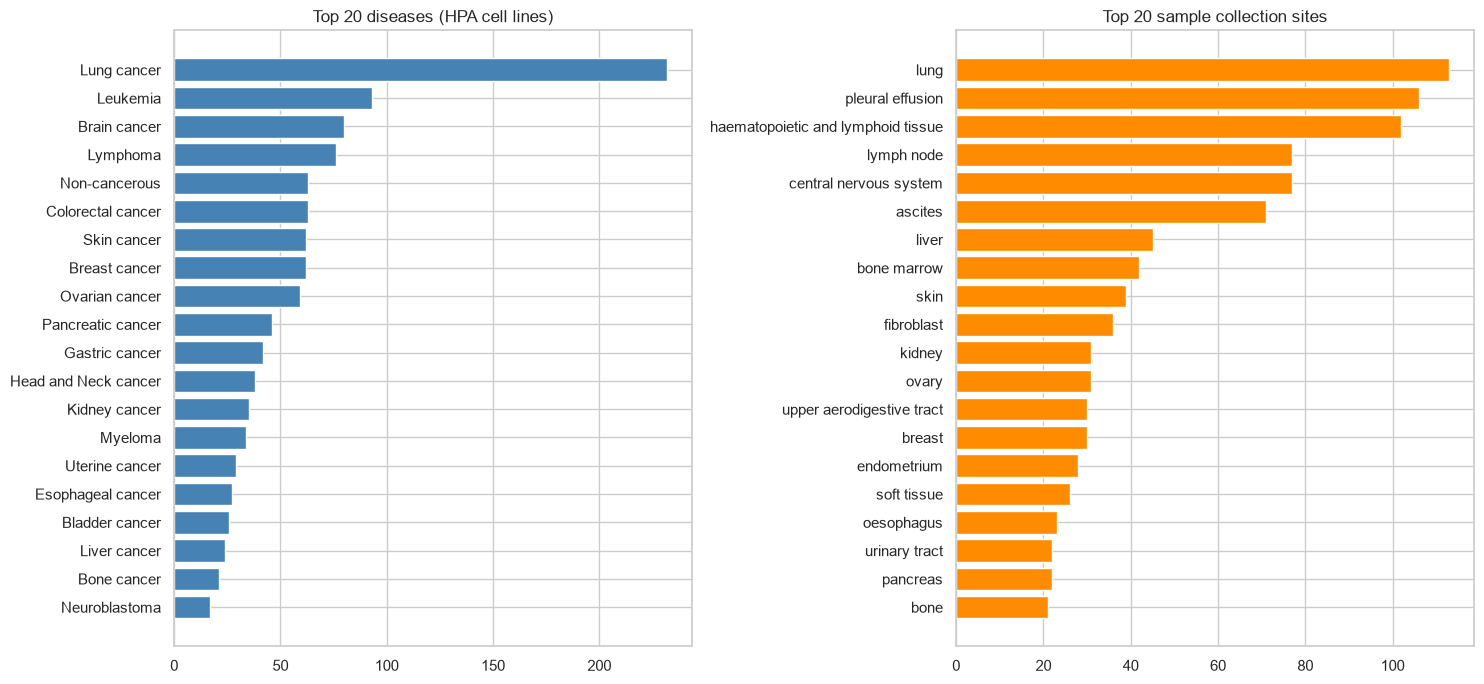

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
top_disease = df['Disease'].value_counts().head(20)
axes[0].barh(top_disease.index[::-1], top_disease.values[::-1], color='steelblue')
axes[0].set_title('Top 20 diseases (HPA cell lines)')

top_site = df['Sample collection site'].value_counts().head(20)
axes[1].barh(top_site.index[::-1], top_site.values[::-1], color='darkorange')
axes[1].set_title('Top 20 sample collection sites')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Gives the HPA-side disease composition to compare against the DepMap-side composition (notebook 09
§2) — a mismatch in which cancers each source emphasises is exactly the kind of coverage
complementarity (or redundancy) that determines whether HPA is worth corroborating against.

## 3. Primary vs. metastasis and disease subtype

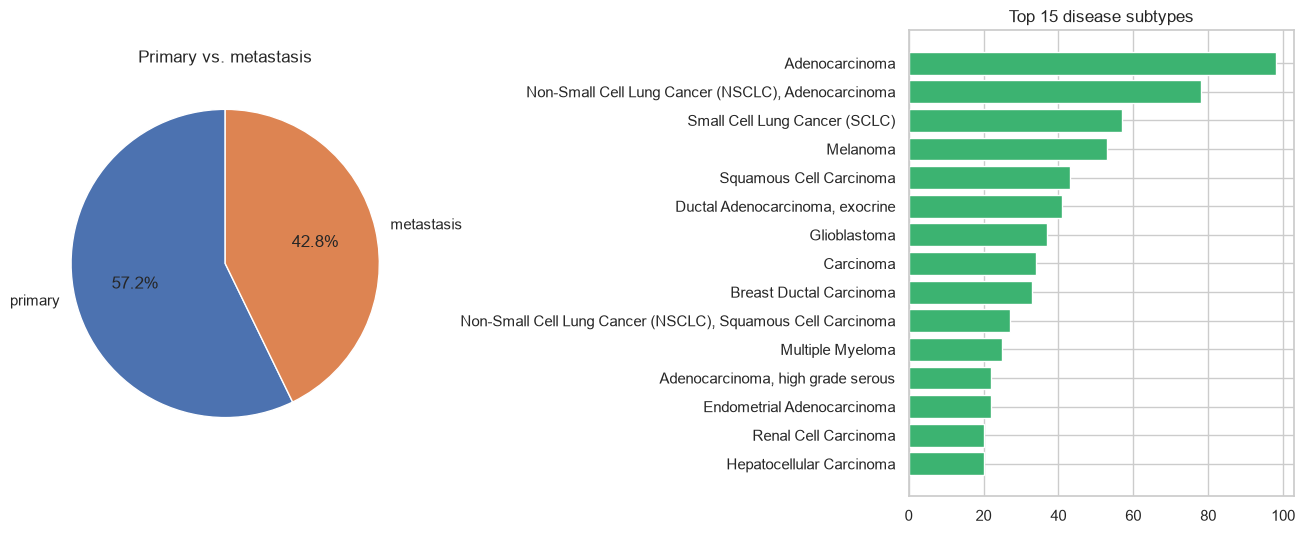

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
pm = df['Primary/Metastasis'].str.lower().str.strip().value_counts()
axes[0].pie(pm.values, labels=pm.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Primary vs. metastasis')

top_sub = df['Disease subtype'].value_counts().head(15)
axes[1].barh(top_sub.index[::-1], top_sub.values[::-1], color='mediumseagreen')
axes[1].set_title('Top 15 disease subtypes')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Same confound root `_.md` §3 flags for the DepMap spine (notebook 09 §3) — a metastasis-heavy
subset within one disease could look like a distinct expression pattern in notebook 01's PCA when
it is really a sampling artefact, not a lineage-level biological difference.

## Decisions carried into the next notebooks

1. This file and HPA expression (file 1) should describe the same 1,206 lines — §1's asymmetry
   check must show near-zero mismatch, or the discrepancy needs investigating before either is
   trusted as complete.
2. HPA's disease composition (§2) is worth comparing against DepMap's (notebook 09) to see where
   the two sources emphasise different cancer types.
3. Primary/metastasis and subtype composition (§3) are confounds to check before any pan-cancer
   HPA-based comparison, same as the DepMap spine.
4. The identity-resolution funnel (`Cell line` → `Cellosaurus ID` → primary spine) is already
   computed in notebook 01 §6 — not repeated here.